In [1]:
# =============
# CARGA DE LIBRERIAS

import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class Transformer(nn.Module):
    def __init__(self, num_points, d_model=128, nhead=8, num_layers=4, dim_feedforward=256):
        super(Transformer, self).__init__()
        self.embedding = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2)
        )
        reduced_len = num_points // 16
        self.positional_encoding = PositionalEncoding(d_model, dropout=0.1, max_len=reduced_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.fc_layers = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = x.transpose(1, 2)
        x = self.pooling(x).squeeze(-1)
        out = self.fc_layers(x)
        return out

num_points = 5000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelTransformer = Transformer(num_points).to(device)

Usando dispositivo: cuda


Correlación lineal: -0.0884
Número de muestras evaluadas: 329989
Error medio: -0.626858


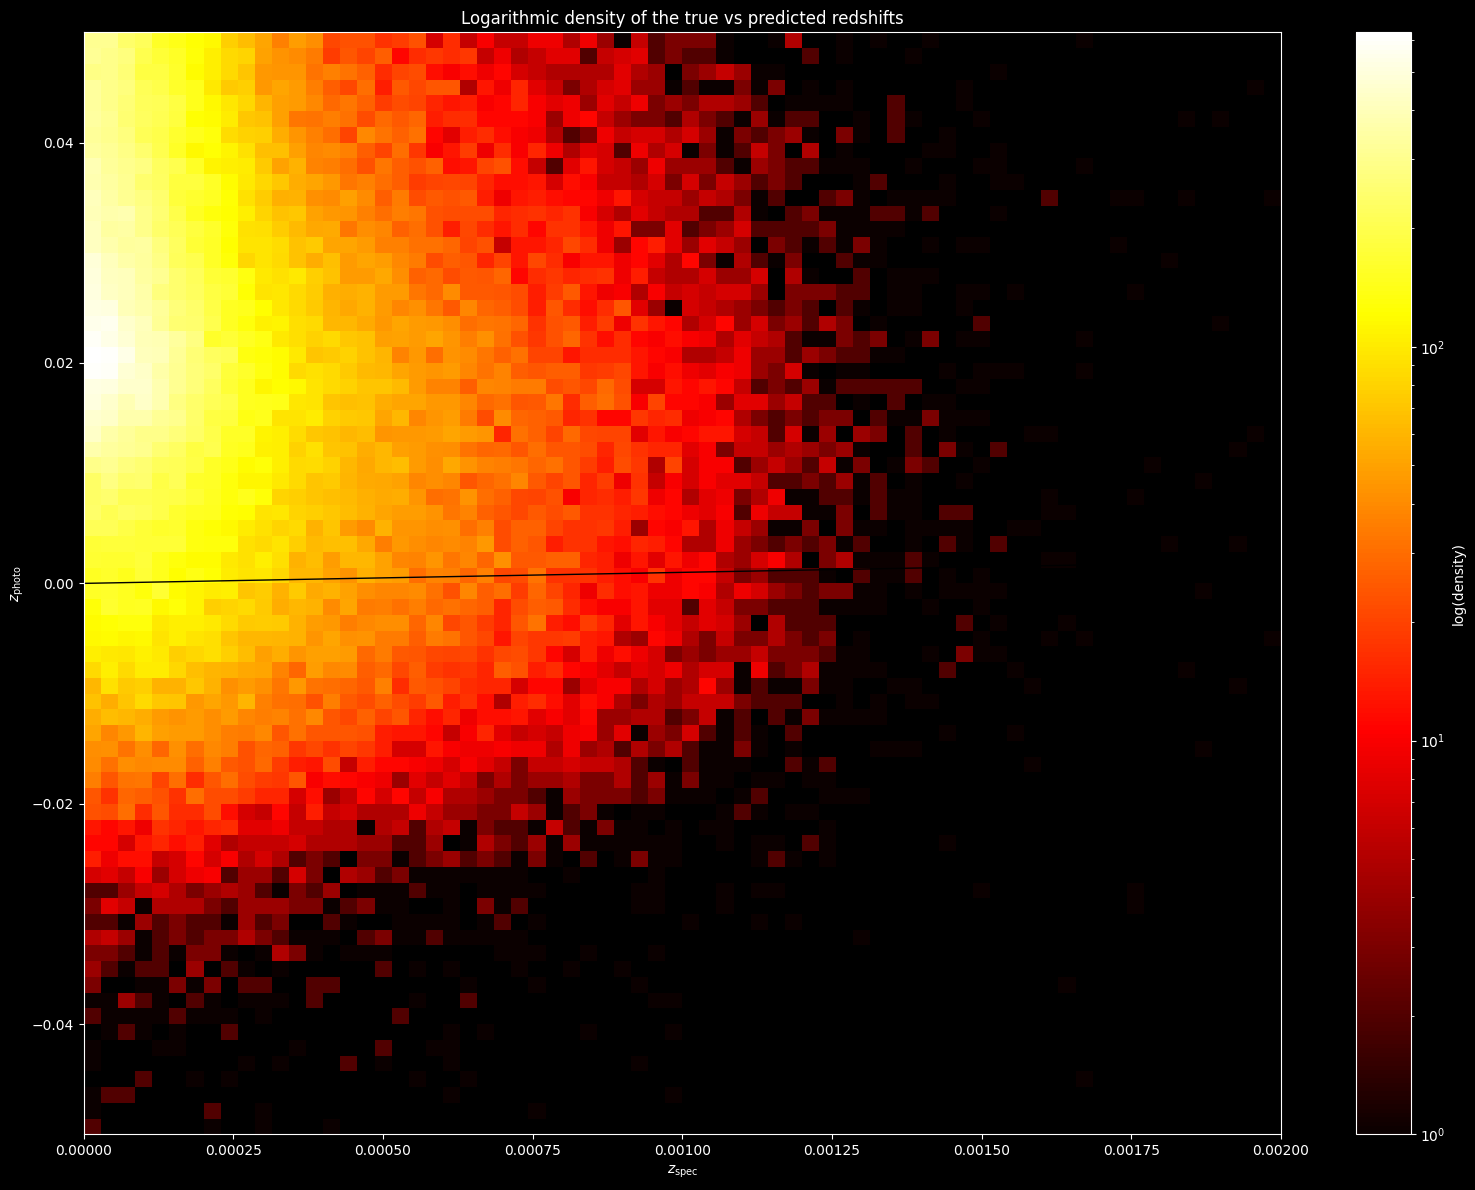

In [3]:
# =============
# EVALUACION EN EL DATASET DE ESTRELLAS

num_points = 5000  # Número de puntos en cada espectro
model_checkpoint = 'storage/modelTRA_1M.pth'  # Ruta del checkpoint del modelo

# Instanciar el modelo y cargar el checkpoint
modelTransformer = Transformer(num_points).to(device)
checkpoint = torch.load(model_checkpoint, map_location=device)
modelTransformer.load_state_dict(checkpoint['model_state_dict'])
modelTransformer.eval()

# Directorios y parámetros
data_dir  = "data"
storage_dir = "storage"
batch_size = 32

# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        data = torch.load(dataset_path)
        self.flux = data["flux"]
        self.wavelength = data["wavelength"]
        self.redshift = data["redshift"]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target
    
    
data_dir = "data"
dataset_path = os.path.join(data_dir, "stars_dataset.pt")
dataset = SpectraDataset(dataset_path)
batch_size = 32
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

predicted = []
real = []

with torch.no_grad():
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        preds = modelTransformer(x_batch).cpu().numpy()  # forma: (batch_size, 1)
        predicted.append(preds)
        real.append(y_batch.numpy())

# Concatenar los resultados de la primera mitad
ypredicted = np.concatenate(predicted, axis=0)
yreal = np.concatenate(real, axis=0)

ypredicted = ypredicted.squeeze()     # Ahora tiene forma (N,)
yreal      = yreal.squeeze()          # Ahora tiene forma (N,)

# Calcular la correlación lineal
correlation = np.corrcoef(yreal, ypredicted)[0, 1]

print(f"Correlación lineal: {correlation:.4f}")
print(f"Número de muestras evaluadas: {len(yreal)}")
print(f"Error medio: {np.mean(yreal - ypredicted):.6f}")

# Mapa de calor de z_real frente a z_predicho estándar

plt.style.use('dark_background')

x_min, x_max = 0, 0.002
y_min, y_max = -0.05, 0.05

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,            # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

Se eliminaron 2 muestras con predicción NaN.
Muestras finales tras enmascarado: 18255
Correlación lineal: 0.8120
Error medio: -0.259271


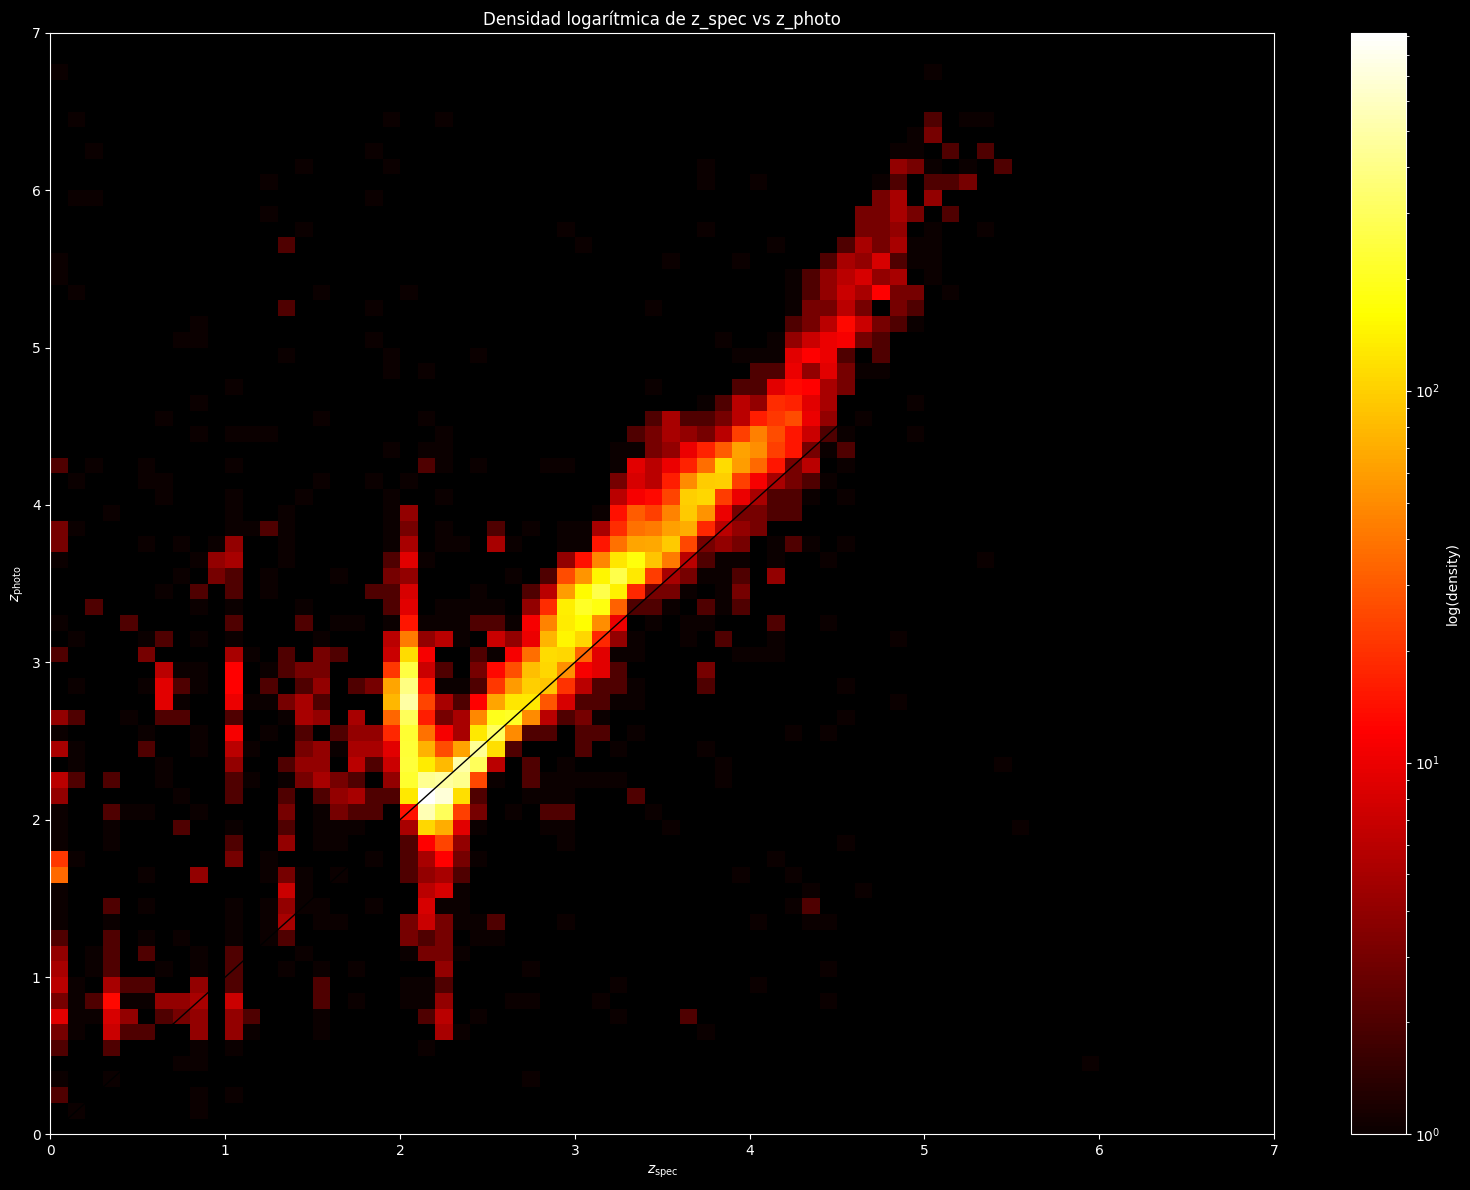

In [4]:
# =============
# EVALUACION EN EL DATASET DE LA NASA

num_points = 5000  # Número de puntos en cada espectro
model_checkpoint = 'storage/modelTRA_1M.pth'  # Ruta del checkpoint del modelo

# Instanciar el modelo y cargar el checkpoint
modelTransformer = Transformer(num_points).to(device)
checkpoint = torch.load(model_checkpoint, map_location=device)
modelTransformer.load_state_dict(checkpoint['model_state_dict'])
modelTransformer.eval()

# Directorios y parámetros
data_dir  = "data"
storage_dir = "storage"
batch_size = 32

# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        data = torch.load(dataset_path)
        self.flux = data["flux"]
        self.wavelength = data["wavelength"]
        self.redshift = data["redshift"]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target
    
    
data_dir = "data"
dataset_path = os.path.join(data_dir, "NASA_dataset.pt")
dataset = SpectraDataset(dataset_path)
batch_size = 32
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

predicted = []
real = []

with torch.no_grad():
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        preds = modelTransformer(x_batch).cpu().numpy()
        predicted.append(preds)
        real.append(y_batch.numpy())

ypredicted = np.concatenate(predicted, axis=0).squeeze()
yreal      = np.concatenate(real, axis=0).squeeze()

# Enmascarar NaNs
# Detectar NaNs en ypredicted
mask_nan = np.isnan(ypredicted)

# Invertir la máscara para quedarnos con valores válidos
mask_valid = ~mask_nan

# Aplicar la máscara a ambos arrays
ypredicted_clean = ypredicted[mask_valid]
yreal_clean      = yreal[mask_valid]

# Reportar cuántos elementos se eliminaron
n_removed = mask_nan.sum()
print(f"Se eliminaron {n_removed} muestras con predicción NaN.")
print(f"Muestras finales tras enmascarado: {len(yreal_clean)}")

# Calcular la correlación lineal con los datos limpios
correlation = np.corrcoef(yreal_clean, ypredicted_clean)[0, 1]
print(f"Correlación lineal: {correlation:.4f}")
print(f"Error medio: {np.mean(yreal_clean - ypredicted_clean):.6f}")

# Mapa de calor de z_real vs z_predicho (limpio)
plt.style.use('dark_background')
x_min, x_max = 0, 7
y_min, y_max = 0, 7
plt.figure(figsize=(16, 12))
counts, xedges, yedges, im = plt.hist2d(
    yreal_clean,
    ypredicted_clean,
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()
)
cbar = plt.colorbar(im, label='log(density)')
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Densidad logarítmica de z_spec vs z_photo')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

Correlación lineal: -0.0554
Número de muestras evaluadas: 329989
Error medio: -0.578874


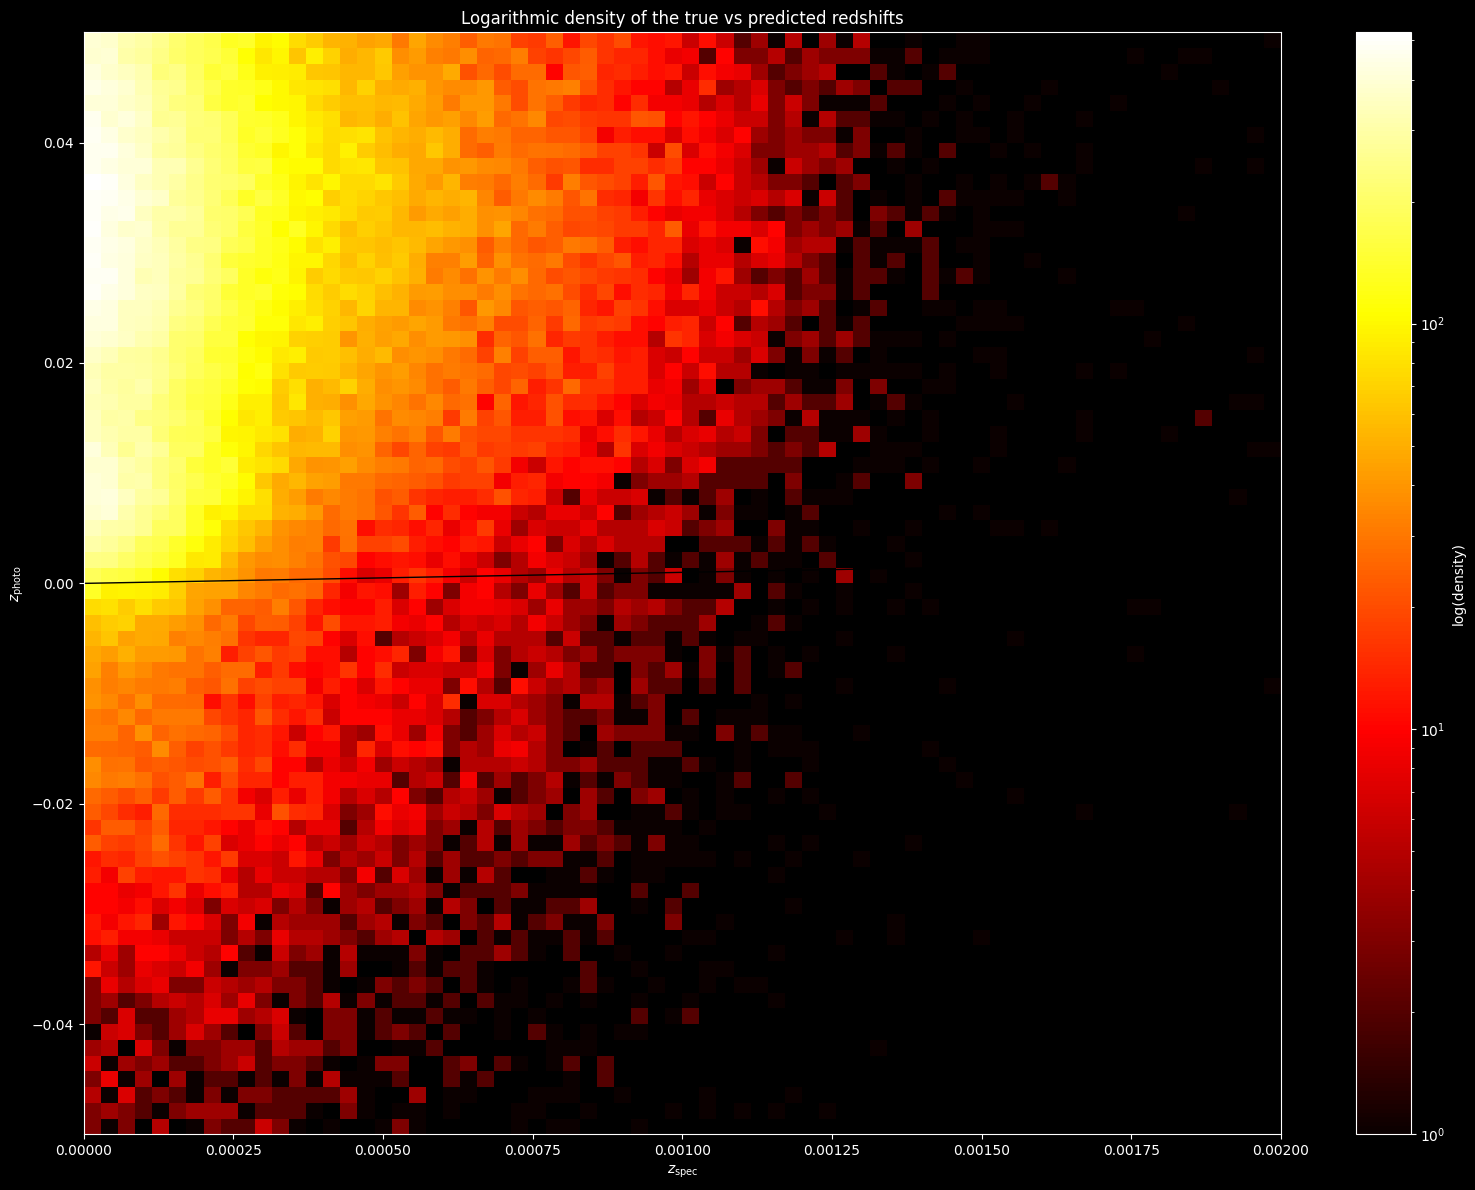

In [5]:
# =============
# EVALUACION EN EL DATASET DE ESTRELLAS

num_points = 5000  # Número de puntos en cada espectro
model_checkpoint = 'storage/modelTRA_1M_renorm.pth'  # Ruta del checkpoint del modelo

# Instanciar el modelo y cargar el checkpoint
modelTransformer = Transformer(num_points).to(device)
checkpoint = torch.load(model_checkpoint, map_location=device)
modelTransformer.load_state_dict(checkpoint['model_state_dict'])
modelTransformer.eval()

# Directorios y parámetros
data_dir  = "data"
storage_dir = "storage"
batch_size = 32

# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        data = torch.load(dataset_path)
        self.flux = data["flux"]
        self.wavelength = data["wavelength"]
        self.redshift = data["redshift"]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target
    
    
data_dir = "data"
dataset_path = os.path.join(data_dir, "stars_dataset_renorm.pt")
dataset = SpectraDataset(dataset_path)
batch_size = 32
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

predicted = []
real = []

with torch.no_grad():
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        preds = modelTransformer(x_batch).cpu().numpy()  # forma: (batch_size, 1)
        predicted.append(preds)
        real.append(y_batch.numpy())

# Concatenar los resultados de la primera mitad
ypredicted = np.concatenate(predicted, axis=0)
yreal = np.concatenate(real, axis=0)

ypredicted = ypredicted.squeeze()     # Ahora tiene forma (N,)
yreal      = yreal.squeeze()          # Ahora tiene forma (N,)

# Calcular la correlación lineal
correlation = np.corrcoef(yreal, ypredicted)[0, 1]

print(f"Correlación lineal: {correlation:.4f}")
print(f"Número de muestras evaluadas: {len(yreal)}")
print(f"Error medio: {np.mean(yreal - ypredicted):.6f}")

# Mapa de calor de z_real frente a z_predicho estándar

plt.style.use('dark_background')

x_min, x_max = 0, 0.002
y_min, y_max = -0.05, 0.05

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,            # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

Se eliminaron 2 muestras con predicción NaN.
Muestras finales tras enmascarado: 18255
Correlación lineal: 0.7200
Error medio: -0.334029


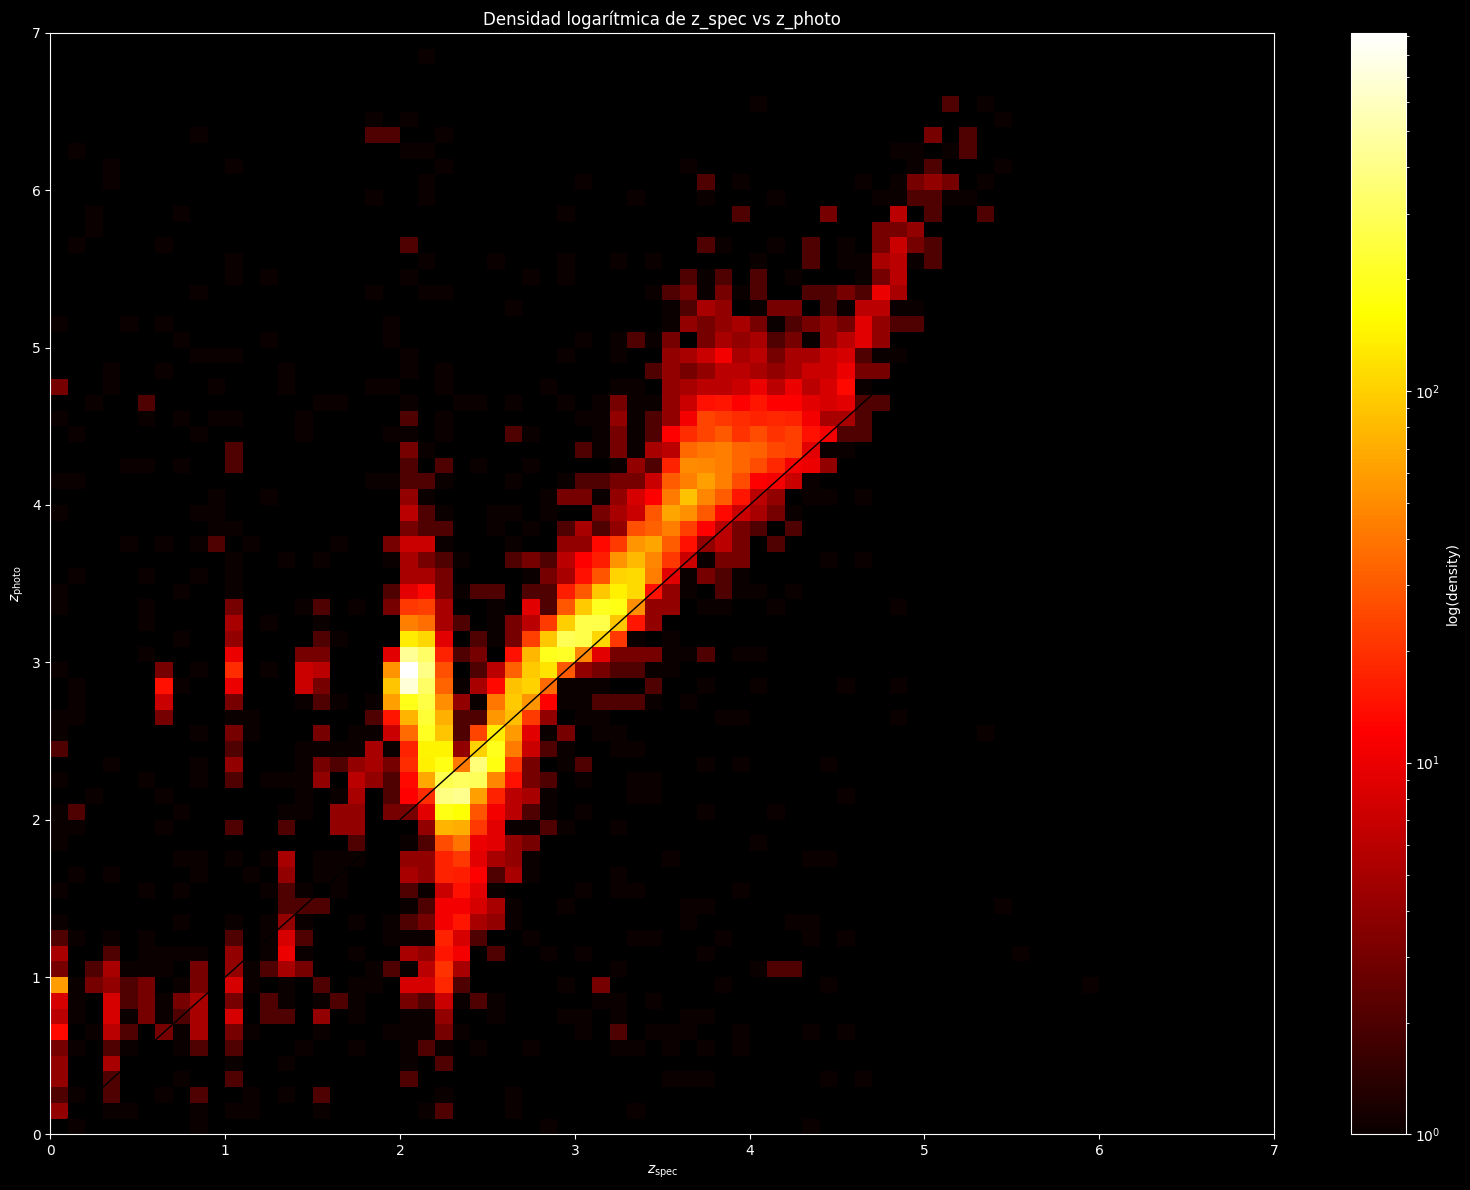

In [6]:
# =============
# EVALUACION EN EL DATASET DE LA NASA

num_points = 5000  # Número de puntos en cada espectro
model_checkpoint = 'storage/modelTRA_1M_renorm.pth'  # Ruta del checkpoint del modelo

# Instanciar el modelo y cargar el checkpoint
modelTransformer = Transformer(num_points).to(device)
checkpoint = torch.load(model_checkpoint, map_location=device)
modelTransformer.load_state_dict(checkpoint['model_state_dict'])
modelTransformer.eval()

# Directorios y parámetros
data_dir  = "data"
storage_dir = "storage"
batch_size = 32

# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        data = torch.load(dataset_path)
        self.flux = data["flux"]
        self.wavelength = data["wavelength"]
        self.redshift = data["redshift"]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target

data_dir = "data"
dataset_path = os.path.join(data_dir, "NASA_dataset_renorm.pt")
dataset = SpectraDataset(dataset_path)
batch_size = 32
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

predicted = []
real = []

with torch.no_grad():
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        preds = modelTransformer(x_batch).cpu().numpy()
        predicted.append(preds)
        real.append(y_batch.numpy())

ypredicted = np.concatenate(predicted, axis=0).squeeze()
yreal      = np.concatenate(real, axis=0).squeeze()

# Enmascarar NaNs
# Detectar NaNs en ypredicted
mask_nan = np.isnan(ypredicted)

# Invertir la máscara para quedarnos con valores válidos
mask_valid = ~mask_nan

# Aplicar la máscara a ambos arrays
ypredicted_clean = ypredicted[mask_valid]
yreal_clean      = yreal[mask_valid]

# Reportar cuántos elementos se eliminaron
n_removed = mask_nan.sum()
print(f"Se eliminaron {n_removed} muestras con predicción NaN.")
print(f"Muestras finales tras enmascarado: {len(yreal_clean)}")

# Calcular la correlación lineal con los datos limpios
correlation = np.corrcoef(yreal_clean, ypredicted_clean)[0, 1]
print(f"Correlación lineal: {correlation:.4f}")
print(f"Error medio: {np.mean(yreal_clean - ypredicted_clean):.6f}")

# Mapa de calor de z_real vs z_predicho (limpio)
plt.style.use('dark_background')
x_min, x_max = 0, 7
y_min, y_max = 0, 7
plt.figure(figsize=(16, 12))
counts, xedges, yedges, im = plt.hist2d(
    yreal_clean,
    ypredicted_clean,
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()
)
cbar = plt.colorbar(im, label='log(density)')
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Densidad logarítmica de z_spec vs z_photo')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

In [7]:
# # Celda independiente: plot de espectros con error ≥ ±0.5
# import numpy as np
# import matplotlib.pyplot as plt

# # Calcular el error absoluto entre z_real y z_predicho
# error = np.abs(yreal_clean - ypredicted_clean)

# # Crear máscara para error ≥ 0.5
# mask_large_error = error >= 1.0

# # Obtener índices de esas muestras
# indices = np.where(mask_large_error)[0]

# # Cargar de nuevo los datos de flux y wavelength completos
# data = torch.load(os.path.join(data_dir, "NASA_dataset_renorm.pt"))
# flux_all       = data["flux"].numpy()
# wavelength_all = data["wavelength"].numpy()

# # Activar modo interactivo
# plt.rcdefaults()
# plt.ion()

# for idx in indices:
#     plt.clf()
#     plt.figure(figsize=(12, 6))
#     plt.plot(wavelength_all[idx], flux_all[idx])
#     plt.title(f"Idx {idx}  |  Δz = {error[idx]:.2f} |  z = {yreal_clean[idx]:.2f}")
#     plt.xlabel("Wave")
#     plt.ylabel("Flux")
#     plt.draw()
#     plt.pause(0.5)

# # Desactivar modo interactivo
# plt.ioff()
# plt.show()